In [71]:
import gymnasium as gym
import lwmr  # noqa: F401 <-- register the environment
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from matplotlib.animation import FuncAnimation
from matplotlib.patches import Polygon
from tqdm.auto import trange

In [72]:
# Specifying the path so that the recording is saved in the project root.
viewer_output_path = "../recordings/lwmr_plane.viser"
env = gym.make(
    "lwmr/Lwmr-v0",
    quiet=True,
    render_mode="viser",
    viewer_output_path=viewer_output_path,
    max_steps=1000,
)

In [ ]:
stopped = (0.0, 0.0, 0.0, 0.0)
forward = (1.0, 1.0, 1.0, 1.0)
veer_right = (1.0, 0.5, 1.0, 0.5)
veer_left = (0.5, 1.0, 0.5, 1.0)
rotate_left = (-1.0, 1.0, -1.0, 1.0)
rotate_right = (1.0, -1.0, 1.0, -1.0)

state_machine = [
    {"action": forward, "condition": lambda info: info.get("event") == "waypoint_hit", "next": 1},
    {"action": rotate_left, "condition": lambda info: abs(info["yaw"] - np.pi / 2) < 0.02, "next": 2},
    {"action": forward, "condition": lambda info: info.get("event") == "waypoint_hit", "next": 3},
    {"action": rotate_right, "condition": lambda info: abs(info["yaw"] - 0.0) < 0.02, "next": 4},
    {"action": forward, "condition": lambda info: info.get("event") == "waypoint_hit", "next": 5},
    {"action": stopped, "condition": lambda info: False, "next": -1},
]

action_index = 0

all_obs = []
all_info = []
rewards = []

env.reset()

num_steps = env.unwrapped.max_steps  # type: ignore
for step in trange(num_steps):
    action = state_machine[action_index]["action"]
    obs, reward, terminated, truncated, info = env.step(action=action)

    all_obs.append(obs)
    all_info.append(info)
    rewards.append(reward)

    env.render()

    if info.get("event"):
        print(f"Event at step {step}: {info['event']}")

    if terminated or truncated:
        print(f"Episode ended at step {step} with info: {info}")
        break

    if state_machine[action_index]["condition"](info):
        action_index = state_machine[action_index]["next"]

env.close()

  0%|          | 0/1000 [00:00<?, ?it/s]

Event at step 88: waypoint_hit
Event at step 252: waypoint_hit
Event at step 417: finished
Episode ended at step 417 with info: {'pos': array([0.99723154, 0.50490814], dtype=float32), 'yaw': np.float32(-0.021903146), 'vel': array([ 0.35817808, -0.00784648], dtype=float32), 'dist': 0.005635089705034253, 'event': 'finished'}


(viser) Server stopped

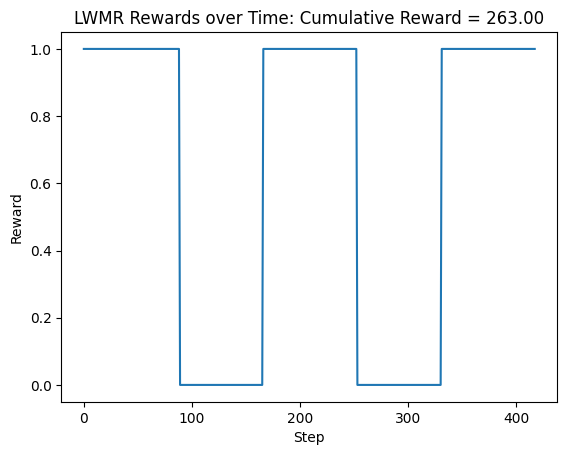

In [74]:
cumulative_reward = np.sum(rewards)
plt.plot(rewards)
plt.xlabel("Step")
plt.ylabel("Reward")
plt.title(f"LWMR Rewards over Time: Cumulative Reward = {cumulative_reward:.2f}");

In [75]:
all_info[0]

{'pos': array([ 5.7500525e-04, -1.3886163e-10], dtype=float32),
 'yaw': np.float32(1.5109997e-10),
 'vel': array([-3.3527613e-08, -9.0061292e-13], dtype=float32),
 'dist': 0.4994249947485514}

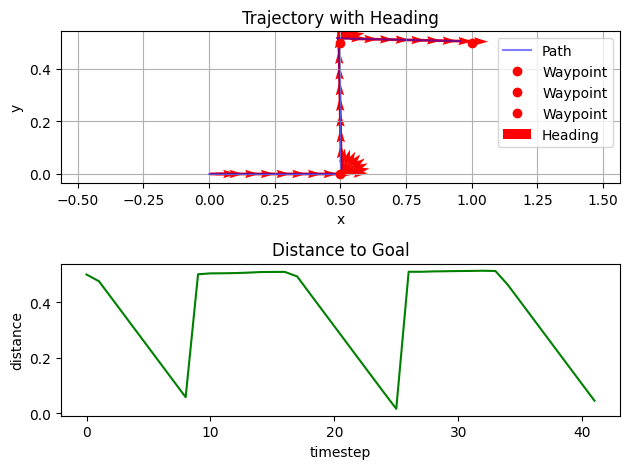

In [76]:
# Plot all info: dict of pos, yaw, vel, dist, events
# Plot all obs: array of
#  [0:2]   body frame velocity (v_x, v_y)
#  [2]     angular velocity (omega)
#  [3:5]   heading sin/cos
#  [5:14]  relative position to waypoint (x_rel, y_rel, magnitude)
#  [14]    progress
#  [15]    cross track error
#  [16:20] previous action (4 values)

decimation = 10

fig, (ax1, ax2) = plt.subplots(nrows=2)

xs = np.array([pose["pos"][0] for pose in all_info[::decimation]])
ys = np.array([pose["pos"][1] for pose in all_info[::decimation]])
yaws = np.array([pose["yaw"] for pose in all_info[::decimation]])
dists = np.array([pose["dist"] for pose in all_info[::decimation] if "dist" in pose])

# Plot the trajectory line
ax1.plot(xs, ys, "b-", alpha=0.5, label="Path")
ax1.plot(0.5, 0.0, "ro", label="Waypoint")
ax1.plot(0.5, 0.5, "ro", label="Waypoint")
ax1.plot(1.0, 0.5, "ro", label="Waypoint")

# Plot heading arrows using quiver
u = np.cos(yaws)  # x-component of heading
v = np.sin(yaws)  # y-component of heading
ax1.quiver(xs, ys, u, v, color="red", scale=20, width=0.005, label="Heading")

ax1.axis("equal")
ax1.grid(True)
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Trajectory with Heading")
ax1.legend()

ax2.plot(dists, "g-")
ax2.set_xlabel("timestep")
ax2.set_ylabel("distance")
ax2.set_title("Distance to Goal")

plt.tight_layout()

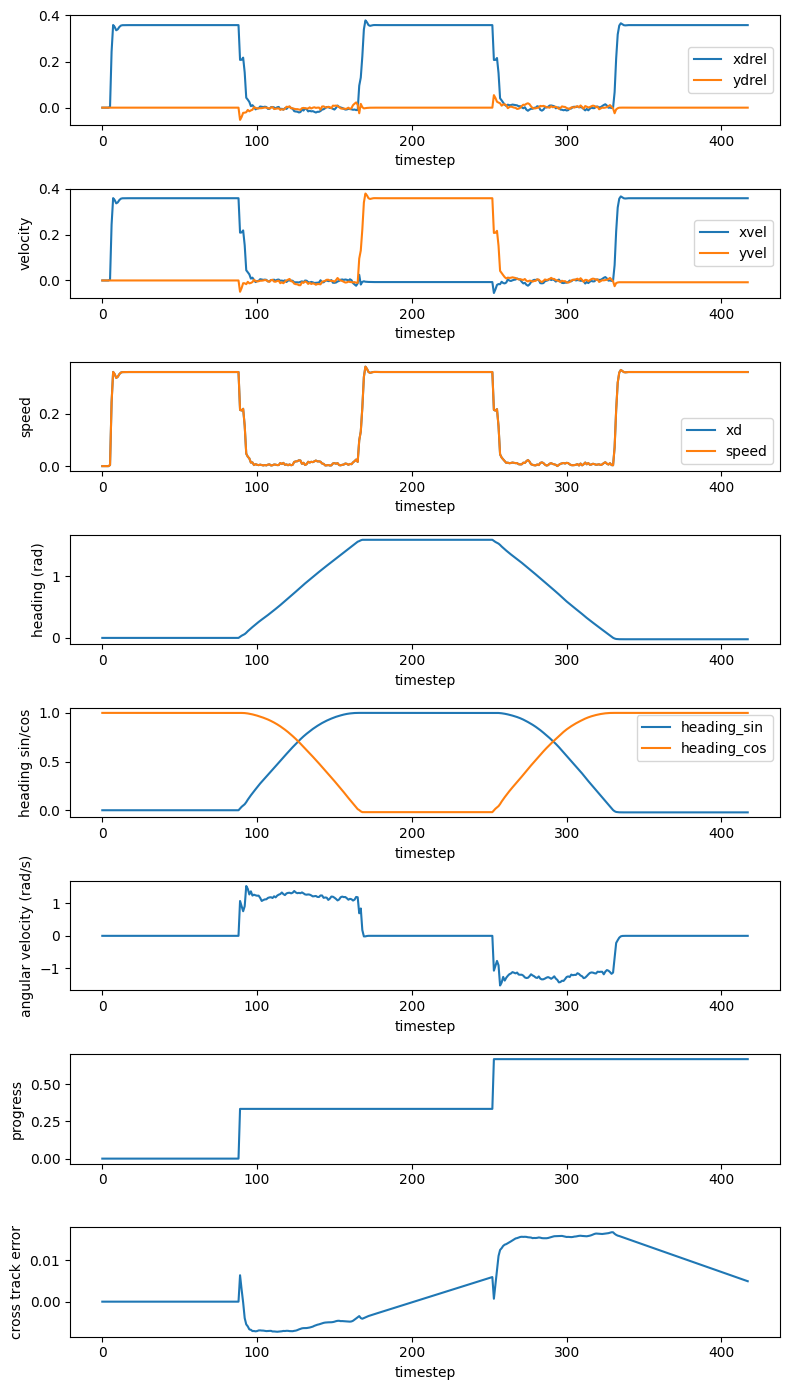

In [77]:
fig, axes = plt.subplots(8, 1, figsize=(8, 14))

obs = np.vstack(all_obs)

axes[0].plot(obs[:, 0], label="xdrel")
axes[0].plot(obs[:, 1], label="ydrel")
axes[0].set_xlabel("timestep")
axes[0].legend()

axes[1].plot([pose["vel"][0] for pose in all_info], label="xvel")
axes[1].plot([pose["vel"][1] for pose in all_info], label="yvel")
axes[1].set_xlabel("timestep")
axes[1].set_ylabel("velocity")
axes[1].legend()

axes[2].plot(np.linalg.norm(obs[:, :2], axis=1), label="xd")
axes[2].plot([np.linalg.norm(pose["vel"][:2]) for pose in all_info], label="speed")
axes[2].set_xlabel("timestep")
axes[2].set_ylabel("speed")
axes[2].legend()

axes[3].plot([pose["yaw"] for pose in all_info])
axes[3].set_xlabel("timestep")
axes[3].set_ylabel("heading (rad)")

axes[4].plot(obs[:, 3], label="heading_sin")
axes[4].plot(obs[:, 4], label="heading_cos")
axes[4].set_xlabel("timestep")
axes[4].set_ylabel("heading sin/cos")
axes[4].legend()

axes[5].plot(obs[:, 2], label="omega")
axes[5].set_xlabel("timestep")
axes[5].set_ylabel("angular velocity (rad/s)")

axes[6].plot(obs[:, 14], label="progress")
axes[6].set_ylabel("progress")

axes[7].plot(obs[:, 15], label="cross track error")
axes[7].set_xlabel("timestep")
axes[7].set_ylabel("cross track error")

plt.tight_layout()

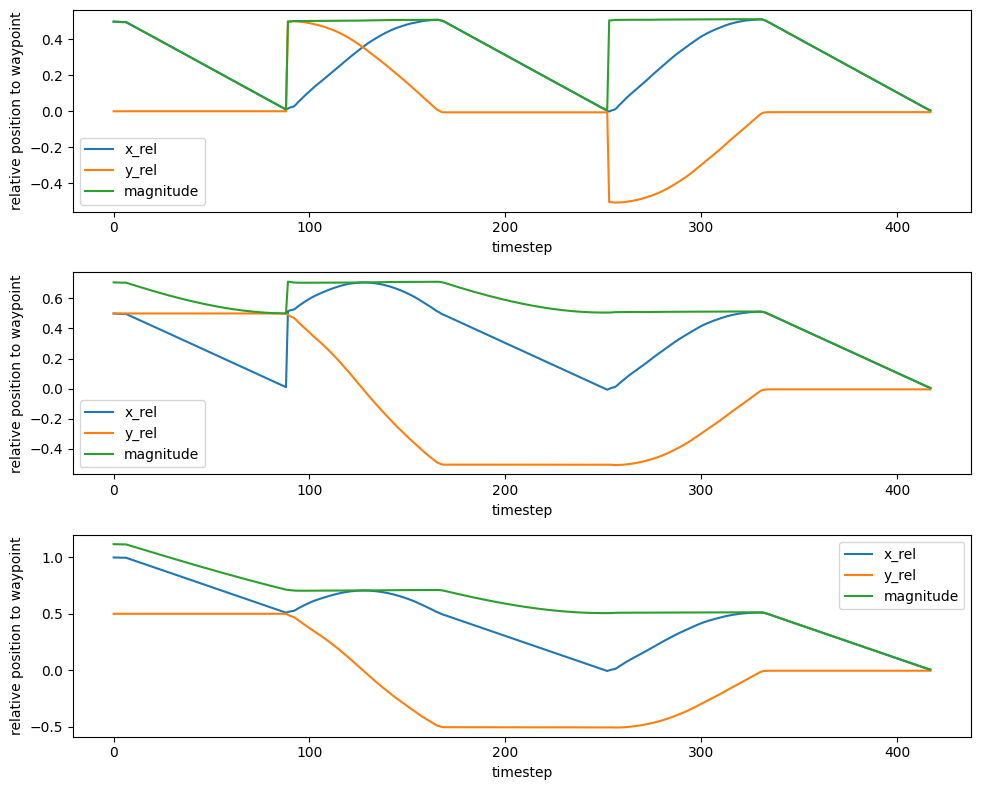

In [78]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 8))

axes[0].plot(obs[:, 5], label="x_rel")
axes[0].plot(obs[:, 6], label="y_rel")
axes[0].plot(obs[:, 7], label="magnitude")
axes[0].set_xlabel("timestep")
axes[0].set_ylabel("relative position to waypoint")
axes[0].legend()

axes[1].plot(obs[:, 8], label="x_rel")
axes[1].plot(obs[:, 9], label="y_rel")
axes[1].plot(obs[:, 10], label="magnitude")
axes[1].set_xlabel("timestep")
axes[1].set_ylabel("relative position to waypoint")
axes[1].legend()

axes[2].plot(obs[:, 11], label="x_rel")
axes[2].plot(obs[:, 12], label="y_rel")
axes[2].plot(obs[:, 13], label="magnitude")
axes[2].set_xlabel("timestep")
axes[2].set_ylabel("relative position to waypoint")
axes[2].legend()

plt.tight_layout()

In [79]:
def animate_trajectory(
    xs,
    ys,
    yaws,
    interval=40,
    max_frames=500,
    triangle_size=0.1,
    arrow_len=0.2,
    trail=True,
    figsize=(8, 6),
):
    xs = xs[:max_frames]
    ys = ys[:max_frames]
    yaws = yaws[:max_frames]

    fig, ax = plt.subplots(figsize=figsize)

    # Set fixed axis limits with padding so the view doesn't jump around
    pad = 0.5
    ax.set_xlim(xs.min() - pad, xs.max() + pad)
    ax.set_ylim(ys.min() - pad, ys.max() + pad)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Animated Trajectory")

    # Faint full path for reference
    ax.plot(xs, ys, color="lightgray", linewidth=1, zorder=1)

    # Trail (path traced so far)
    (trail_line,) = ax.plot([], [], "b-", linewidth=2, zorder=2)

    # Heading arrow
    heading_arrow = ax.quiver(
        [xs[0]],
        [ys[0]],
        [np.cos(yaws[0])],
        [np.sin(yaws[0])],
        color="red",
        scale=1 / arrow_len,
        scale_units="xy",
        angles="xy",
        width=0.006,
        zorder=4,
    )

    # Pose triangle
    base_tri = np.array(
        [
            [triangle_size, 0],
            [-triangle_size / 2, triangle_size / 2],
            [-triangle_size / 2, -triangle_size / 2],
        ]
    )

    def rotate_translate(pts, xc, yc, theta):
        c, s = np.cos(theta), np.sin(theta)
        R = np.array([[c, -s], [s, c]])
        return pts @ R.T + np.array([xc, yc])

    pose_patch = Polygon(
        rotate_translate(base_tri, xs[0], ys[0], yaws[0]),
        closed=True,
        color="blue",
        alpha=0.7,
        zorder=3,
    )
    ax.add_patch(pose_patch)

    # Step / time text
    txt = ax.text(
        0.02,
        0.98,
        "",
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    def init():
        trail_line.set_data([], [])
        return trail_line, heading_arrow, pose_patch, txt

    def update(i):
        if trail:
            trail_line.set_data(xs[: i + 1], ys[: i + 1])

        # Update heading arrow position + direction
        heading_arrow.set_offsets(np.array([[xs[i], ys[i]]]))
        heading_arrow.set_UVC(np.cos(yaws[i]), np.sin(yaws[i]))

        # Update pose triangle
        pose_patch.set_xy(rotate_translate(base_tri, xs[i], ys[i], yaws[i]))

        txt.set_text(f"step: {i + 1}/{len(xs)}\nx={xs[i]:.2f}, y={ys[i]:.2f}, yaw={np.degrees(yaws[i]):.1f}°")
        return trail_line, heading_arrow, pose_patch, txt

    anim = FuncAnimation(fig, update, frames=len(xs), init_func=init, interval=interval, blit=False)
    plt.close(fig)  # prevents duplicate static figure in Jupyter
    return anim


anim = animate_trajectory(xs, ys, yaws, interval=40)
HTML(anim.to_jshtml())
# anim.save('trajectory.mp4', fps=25)  # optional: save to file (needs ffmpeg)